In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv('Amazon Sale report.csv')

# 2. Check rows and columns count
print("Dataset Shape:", df.shape)

# 3. Check columns and data types
print("\n--- Dataset Info ---")
print(df.info())

# 4. View first 5 rows
df.head()

/tmp/ipykernel_12539/3382280925.py:5: DtypeWarning: Columns (21,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Amazon Sale Report.csv') # Un file name-ah inga poodu


Dataset Shape: (111942, 24)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111942 entries, 0 to 111941
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               111942 non-null  int64  
 1   Order ID            111942 non-null  object 
 2   Date                111942 non-null  object 
 3   Status              111942 non-null  object 
 4   Fulfilment          111942 non-null  object 
 5   Sales Channel       111942 non-null  object 
 6   ship-service-level  111942 non-null  object 
 7   Style               111942 non-null  object 
 8   SKU                 111942 non-null  object 
 9   Category            111942 non-null  object 
 10  Size                111942 non-null  object 
 11  ASIN                111942 non-null  object 
 12  Courier Status      105800 non-null  object 
 13  Qty                 111942 non-null  int64  
 14  currency            105157 non-nul

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [2]:
# 1. Check total count of missing fields per column
print("Missing values per column before cleaning:")
print(df.isnull().sum())

# 2. Drop columns that are completely empty if any exist
df = df.dropna(how='all')

# 3. Handle duplicate records to secure analytical integrity
print(f"\nTotal duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()

# 4. Check for critical status/numerical columns and clean missing rows
# Drop rows where critical info like 'Amount' or 'Status' is blank
if 'Amount' in df.columns:
    df = df.dropna(subset=['Amount'])

print("\nData Cleaning Completed successfully!")
print("New Cleaned Dataset Shape:", df.shape)

Missing values per column before cleaning:
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6142
Qty                       0
currency               6785
Amount                 6785
ship-city                27
ship-state               27
ship-postal-code         27
ship-country             28
promotion-ids         41913
B2B                       1
fulfilled-by          76822
Unnamed: 22           49051
dtype: int64

Total duplicate rows found: 0

Data Cleaning Completed successfully!
New Cleaned Dataset Shape: (105157, 24)


In [4]:
import pandas as pd

# 1. Generate descriptive summary statistics for numerical variables
print("--- Statistical Summary ---")
print(df.describe())

# 2. Categorical dynamic frequency distribution
# Checking performance variations across Order Status profiles
if 'Status' in df.columns:
    print("\n--- Order Status Distribution Count ---")
    print(df['Status'].value_counts().head(10))

--- Statistical Summary ---
               index            Qty         Amount  ship-postal-code
count  105157.000000  105157.000000  105157.000000     105132.000000
mean    55953.862235       0.959984     646.886597     463429.877021
std     32291.841071       0.216296     280.264248     192004.611779
min         0.000000       0.000000       0.000000         84.000000
25%     28019.000000       1.000000     448.000000     382110.000000
50%     55984.000000       1.000000     599.000000     500030.000000
75%     83844.000000       1.000000     788.000000     600023.000000
max    111941.000000       8.000000    5584.000000     989898.000000

--- Order Status Distribution Count ---
Status
Shipped                          66405
Shipped - Delivered to Buyer     25576
Cancelled                         9362
Shipped - Returned to Seller      1722
Shipped - Picked Up                966
Pending                            655
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller 

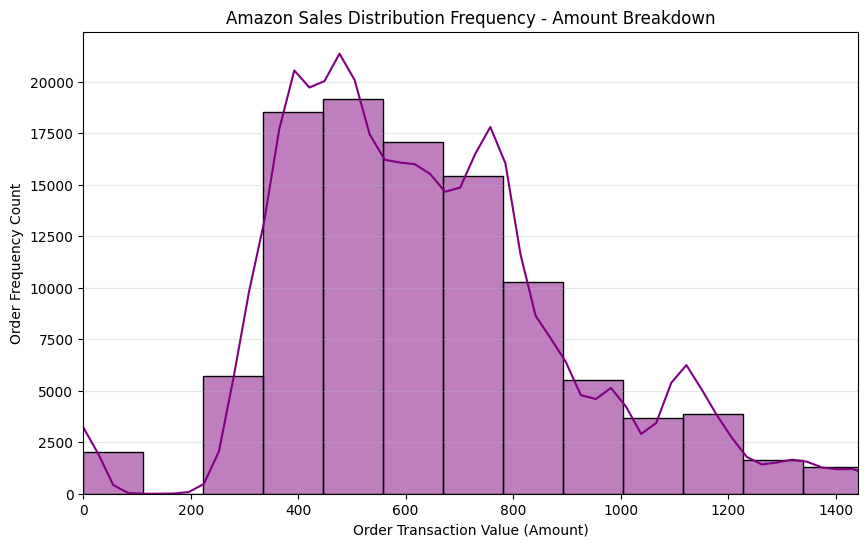

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize visualization environment setup
plt.figure(figsize=(10, 6))

# 2. If 'Amount' distribution column exists, plot structural density histogram
if 'Amount' in df.columns:
    sns.histplot(df['Amount'], bins=50, kde=True, color='purple')
    plt.title('Amazon Sales Distribution Frequency - Amount Breakdown')
    plt.xlabel('Order Transaction Value (Amount)')
    plt.ylabel('Order Frequency Count')

    # Dynamic scaling for long-tail outliers mapping
    plt.xlim(0, df['Amount'].quantile(0.99))
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print("Specified dynamic metric column not detected for plotting.")